## Titanic dataset from Claude AI

- In this note book we'll use claude ai to learn about the titanic dataset and how claude ai can teach in it.

### 1. Set up and load the dataset

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 2. First look - understand the shape and structure

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
         survived      pclass         age       sibsp       parch        fare
c

### 3. Check for missing data specifically.

In [4]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### 4. Decide a cleaning strategy for each column

- **age (177 missing)** - a meaning full column, too many missing values to just drop rows.
- Best approach: fill with the **median** (robust to outliers, unlike mean)

In [5]:
df['age'] = df['age'].fillna(df['age'].median())

- **embarked (2 missing)** - categorical, only 2 missing out of 891 rows. Safe to fill with the most common value (mode).

In [6]:
df['embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [7]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

- **embark_town (2 missing)** - same rows as **embarked** likely. Same approach

In [8]:
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

- **deck (688 missing out of 891)** - this is **77% missing**. Filling this in would mostly be guessing.
- Best approach: **drop the column entirely** rather than fill it. 

In [9]:
df = df.drop(columns=['deck'])

### 5. Verify cleaning worked

In [10]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

### 6. Check for duplicate rows (good habit)

In [11]:
print(df.duplicated().sum())

116


- if greater than 0:

In [12]:
df = df.drop_duplicates()

In [13]:
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

### 7. Overall Survival Rate

In [14]:
survival_rate = df['survived'].mean()

print(f'Overall survival rate: {survival_rate.round(2)}')

Overall survival rate: 0.41


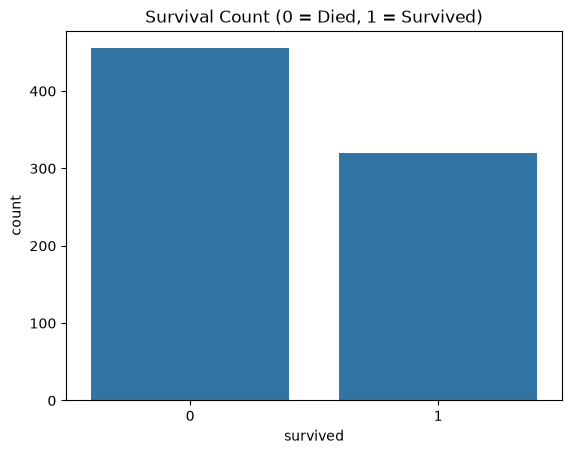

In [15]:
sns.countplot(data=df, x='survived')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.show()

### 8. Survival by sex - a well known factor ("women and children first")

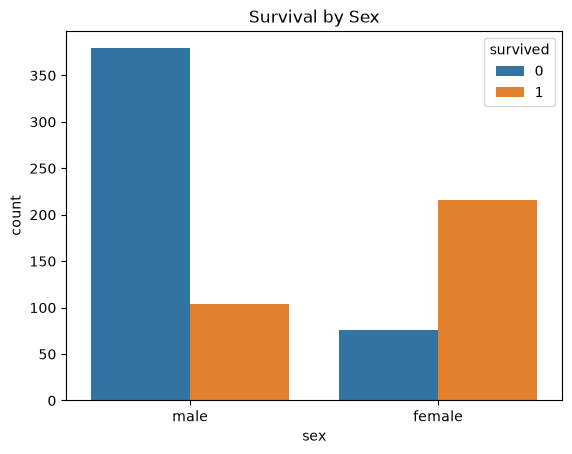

In [16]:
sns.countplot(data=df, x='sex', hue='survived')
plt.title('Survival by Sex')
plt.show()

In [17]:
df.groupby('sex')['survived'].mean().round(2)

sex
female    0.74
male      0.22
Name: survived, dtype: float64

### 9. Survival by Passenger class

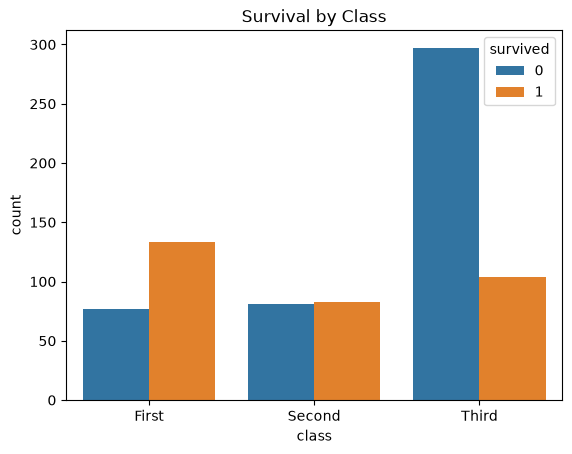

In [18]:
sns.countplot(data=df, x='class', hue='survived')
plt.title('Survival by Class')
plt.show()

In [19]:
df.groupby('class')['survived'].mean().round(2)

class
First     0.63
Second    0.51
Third     0.26
Name: survived, dtype: float64

### 10. Age distribution - did age matter?

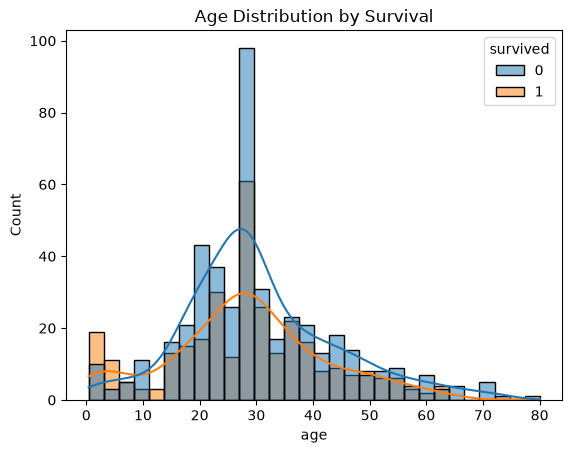

In [20]:
sns.histplot(data=df, x='age', hue='survived', bins=30, kde=True)
plt.title('Age Distribution by Survival')
plt.show()

### 11. Combine class AND sex together (richer insight)

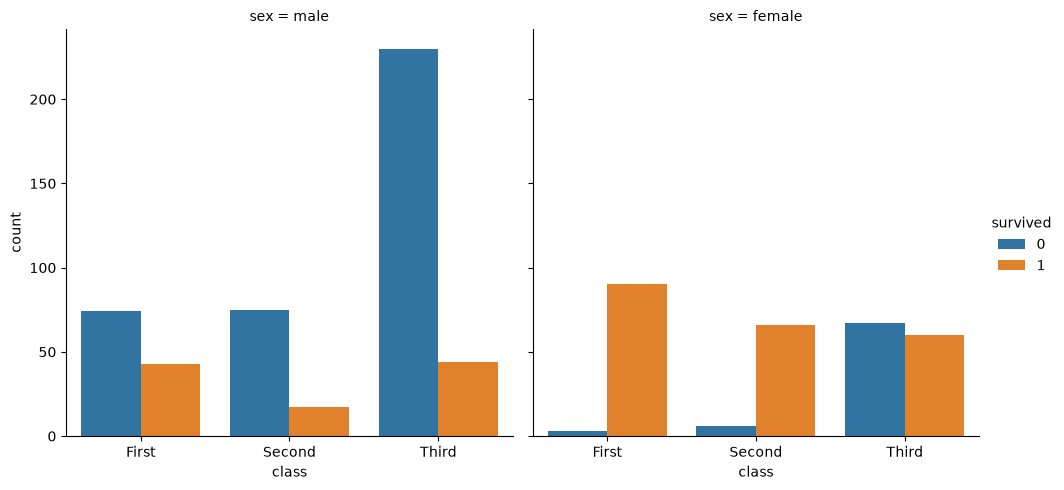

In [21]:
sns.catplot(data=df, x='class', hue='survived', col='sex', kind='count')
plt.show()

### 12. Quantify this with exact survival rates

In [22]:
df.groupby(['sex', 'class'])['survived'].mean()

sex     class 
female  First     0.967742
        Second    0.916667
        Third     0.472441
male    First     0.367521
        Second    0.184783
        Third     0.160584
Name: survived, dtype: float64

- This gives you the precise percentages behind what you're seeing visually -- much more precise than eyeballing bar heights.

### 13. Explore fare - did wealthier passengers (higher fare) survive more?

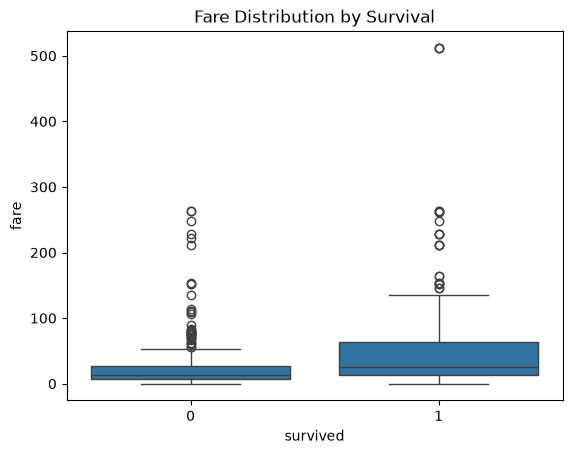

In [23]:
sns.boxplot(data=df, x='survived', y='fare')
plt.title('Fare Distribution by Survival')
plt.show()

### 14. Correlation heatmap - see relationships between all numeric variables once

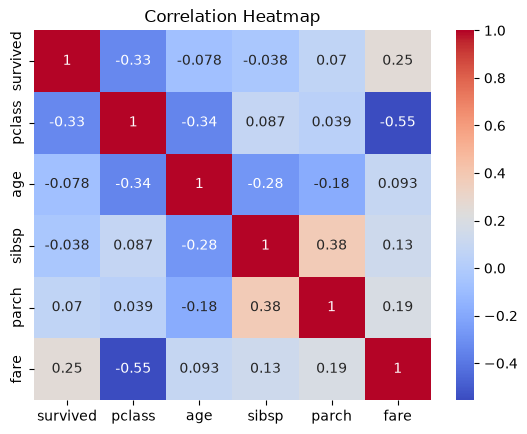

In [25]:
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()